# K-Means Clustering (Unsupervised Learning)

**Dataset:** Mall Customer Segmentation  
**Goal:** Group customers into meaningful segments based on Annual Income and Spending Score  
**Algorithm:** K-Means

## 1. Import Libraries

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples


## 2. Load Dataset

**Mall Customer Segmentation Data**  
- 200 customers from a shopping mall  
- Features: `CustomerID`, `Genre`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`  
- Source: [Mall-Customer-Segmentation-Data (GitHub)](https://github.com/kennedykwangari/Mall-Customer-Segmentation-Data)

In [17]:
df = pd.read_csv('Mall_Customers.csv')
print('Shape:', df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Exploratory Data Analysis (EDA)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [19]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [20]:
# Missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


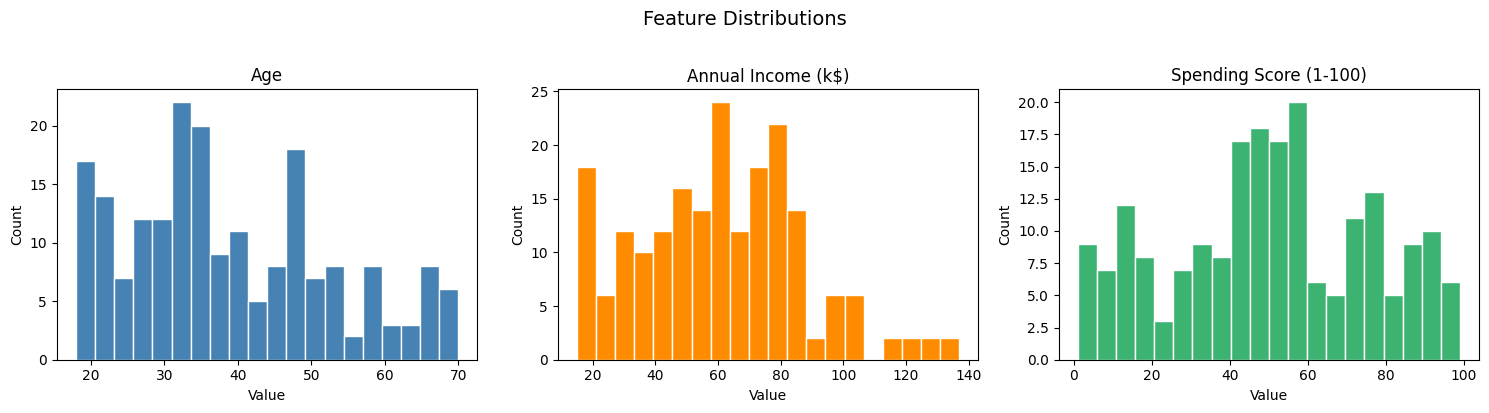

In [21]:
# Distribution of each numeric feature
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors   = ['steelblue', 'darkorange', 'mediumseagreen']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat, col in zip(axes, features, colors):
    ax.hist(df[feat], bins=20, color=col, edgecolor='white')
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

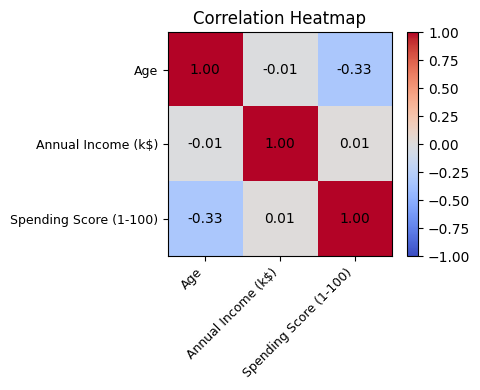

In [22]:
# Correlation heatmap
corr = df[features].corr()
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(features, fontsize=9)
for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=10)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [23]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Shape:', X_scaled.shape)

Shape: (200, 2)


## 5. Find Optimal K

### 5.1 Elbow Method

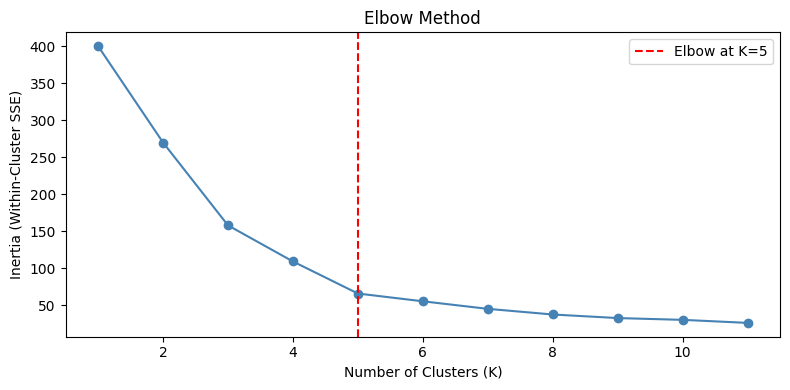

In [24]:
inertia = []
K_range = range(1, 12)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='steelblue')
plt.axvline(x=5, color='red', linestyle='--', label='Elbow at K=5')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster SSE)')
plt.title('Elbow Method')
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Silhouette Analysis

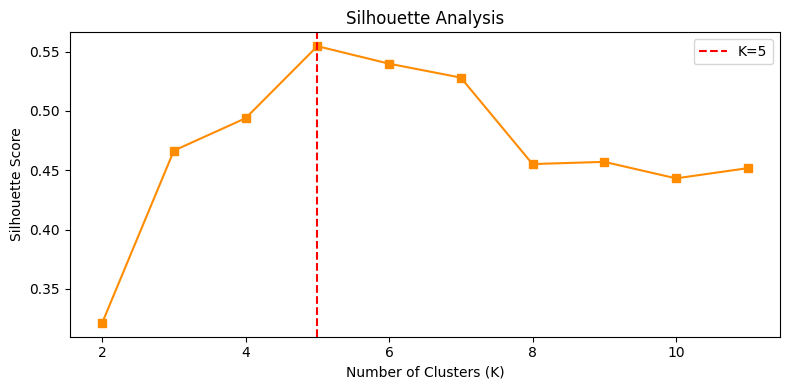

Best K by Silhouette: 5  (score=0.5547)


In [25]:
sil_scores = []
K_range2 = range(2, 12)

for k in K_range2:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(list(K_range2), sil_scores, marker='s', color='darkorange')
plt.axvline(x=5, color='red', linestyle='--', label='K=5')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.legend()
plt.tight_layout()
plt.show()

best_k = list(K_range2)[np.argmax(sil_scores)]
print(f'Best K by Silhouette: {best_k}  (score={max(sil_scores):.4f})')

## 6. Train K-Means Model (K = 5)

In [26]:
K_BEST = 5
kmeans = KMeans(n_clusters=K_BEST, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = kmeans_labels
print('Silhouette Score:', round(silhouette_score(X_scaled, kmeans_labels), 4))
print('\nCluster counts:')
print(df['Cluster'].value_counts().sort_index())

Silhouette Score: 0.5547

Cluster counts:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


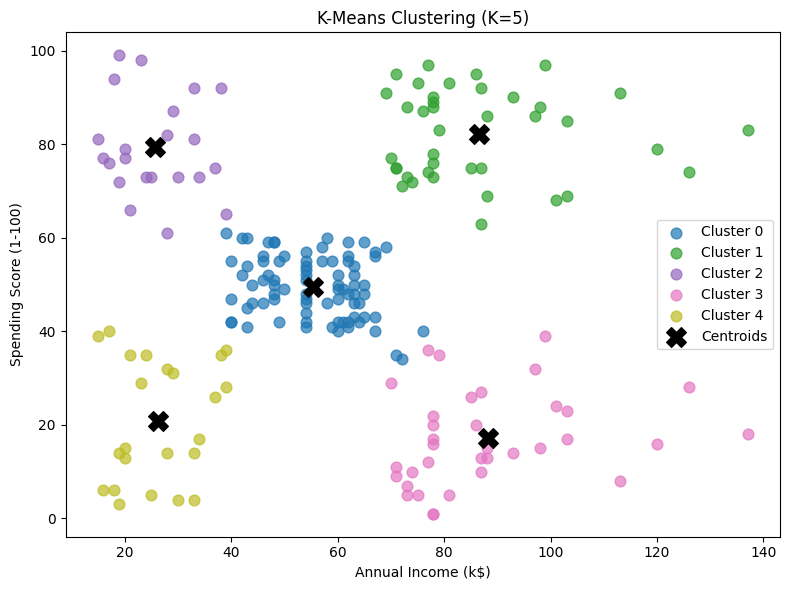

In [27]:
# Cluster scatter plot with centroids
colors = [cm.tab10(i / K_BEST) for i in range(K_BEST)]
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
for cluster_id in range(K_BEST):
    mask = kmeans_labels == cluster_id
    plt.scatter(X[mask, 0], X[mask, 1],
                label=f'Cluster {cluster_id}', color=colors[cluster_id], alpha=0.7, s=60)

plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
            marker='X', s=200, color='black', zorder=5, label='Centroids')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering (K=5)')
plt.legend()
plt.tight_layout()
plt.show()

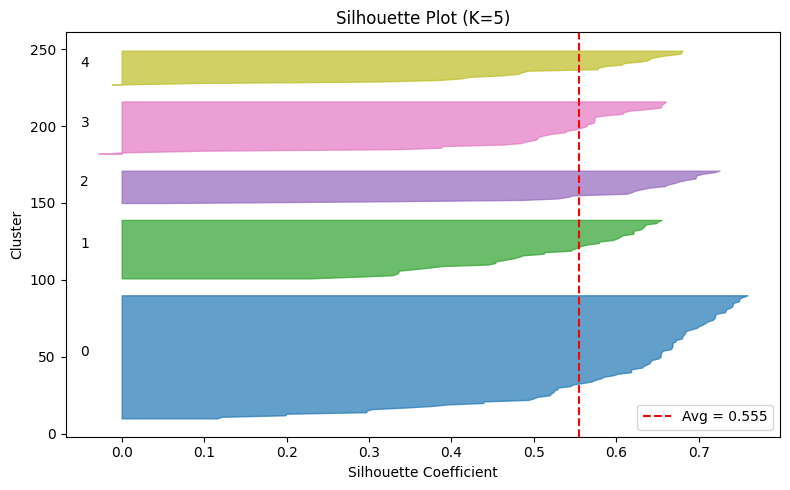

In [28]:
# Silhouette plot
fig, ax = plt.subplots(figsize=(8, 5))
sample_sil = silhouette_samples(X_scaled, kmeans_labels)
y_lower = 10

for i in range(K_BEST):
    ith_cluster_sil = np.sort(sample_sil[kmeans_labels == i])
    size = ith_cluster_sil.shape[0]
    y_upper = y_lower + size
    color = cm.tab10(i / K_BEST)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

avg_score = silhouette_score(X_scaled, kmeans_labels)
ax.axvline(x=avg_score, color='red', linestyle='--', label=f'Avg = {avg_score:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot (K=5)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Cluster Profile Analysis

In [14]:
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print('Cluster Profiles:')
profile

Cluster Profiles:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.7,55.3,49.5
1,32.7,86.5,82.1
2,25.3,25.7,79.4
3,41.1,88.2,17.1
4,45.2,26.3,20.9


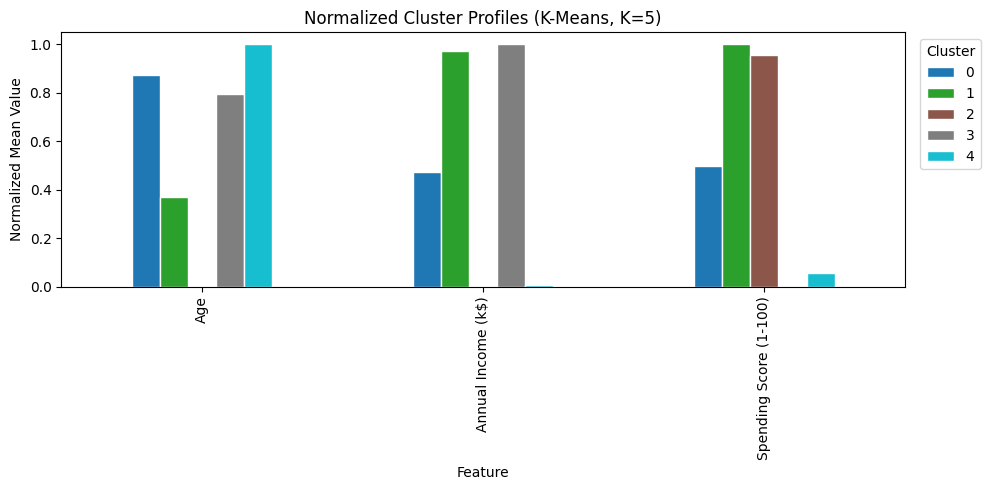

In [15]:
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

ax = profile_norm.T.plot(kind='bar', figsize=(10, 5), colormap='tab10', edgecolor='white')
ax.set_title('Normalized Cluster Profiles (K-Means, K=5)')
ax.set_xlabel('Feature')
ax.set_ylabel('Normalized Mean Value')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 9. Summary

| Cluster | Annual Income | Spending Score | Segment Description |
|---------|--------------|----------------|---------------------|
| 0 | Low | Low | Budget-conscious customers |
| 1 | High | Low | Careful savers |
| 2 | Medium | Medium | Average customers |
| 3 | Low | High | Impulsive buyers |
| 4 | High | High | Target VIP customers |